# Bài tập 2: Kiểm tra White Noise

Mục tiêu:
- Sinh ra một chuỗi dữ liệu hoàn toàn ngẫu nhiên (Nhiễu trắng - White Noise).
- Vẽ và quan sát biểu đồ ACF của White Noise xem các lag có nằm gọn trong dải tin cậy 95% không.
- So sánh với biểu đồ ACF của dữ liệu raw (dữ liệu nhiệt độ tại Bài 1).

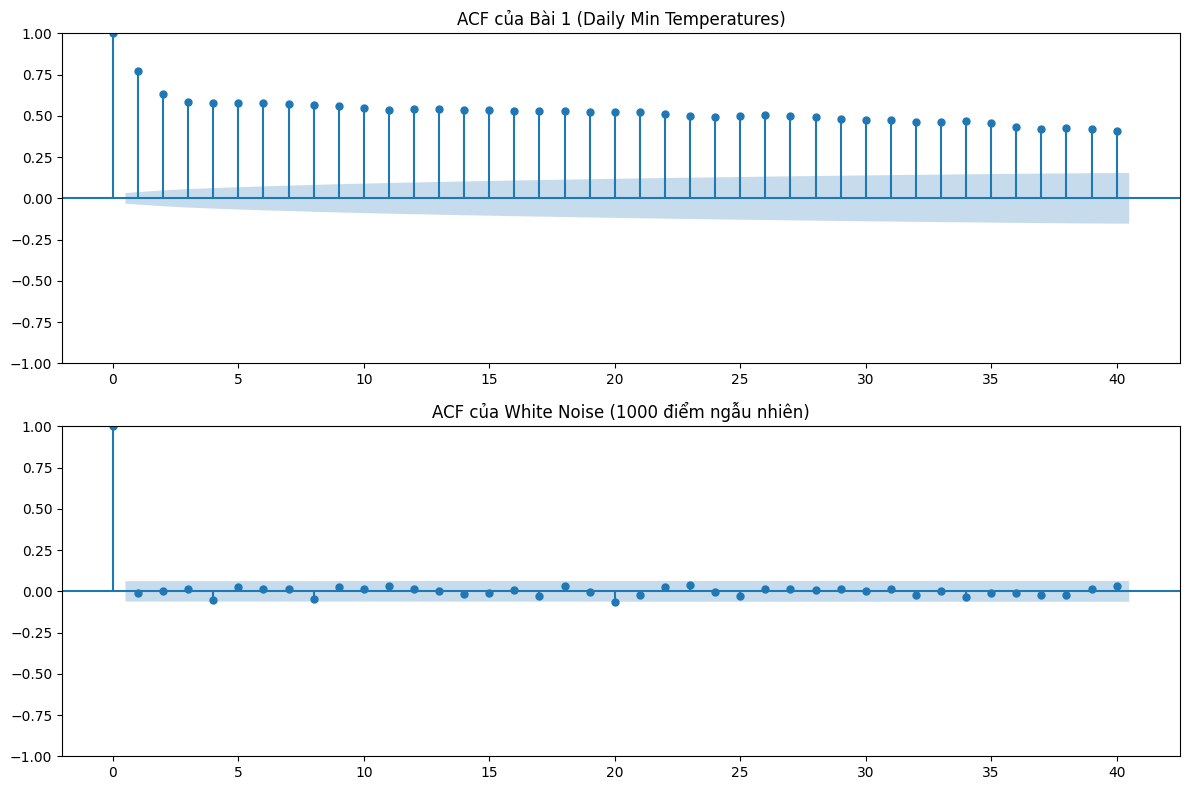

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

# 1. Tải dữ liệu Bài 1 để cần so sánh
# Lưu ý đường dẫn file csv phải chính xác như Bài 1
df = pd.read_csv('/content/daily-min-temperatures.csv', parse_dates=['Date'], index_col='Date')

# 2. Sinh dữ liệu random lam white noise (1000 điểm)
np.random.seed(42)
white_noise = np.random.normal(loc=0, scale=1, size=1000)

# 3. Vẽ biểu đồ ACF sự so sánh
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# ACF của mỏi Temps
plot_acf(df['Temp'], lags=40, ax=axes[0])
axes[0].set_title('ACF của Bài 1 (Daily Min Temperatures)')

# ACF của White Noise
plot_acf(white_noise, lags=40, ax=axes[1])
axes[1].set_title('ACF của White Noise (1000 điểm ngẫu nhiên)')

plt.tight_layout()
plt.show()

In [3]:
# 4. Kiểm tra độ tin cậy 95%
acf_values, confint = acf(white_noise, nlags=40, alpha=0.05)

# Ngưỡng tin cậy 95% của chuỗi không tự tương quan xấp xỉ +- 1.96 / sqrt(N)
ci_bound = 1.96 / np.sqrt(1000)
lags_outside = sum(np.abs(acf_values[1:]) > ci_bound) # Bỏ qua lag 0 (luôn bằng 1)

print(f'Tổng số lag được kiểm tra: 40')
print(f'Số lag vượt khỏi dải tin cậy 95%: {lags_outside}')
print(f'Tỷ lệ lag nằm trong vùng an toàn: {(40 - lags_outside)/40 * 100}%')

Tổng số lag được kiểm tra: 40
Số lag vượt khỏi dải tin cậy 95%: 1
Tỷ lệ lag nằm trong vùng an toàn: 97.5%


/tmp/ipykernel_2264/3801145490.py:2: FutureWarning: acf currently returns a plain tuple whose length depends on the qstat and alpha arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an AcfResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  acf_values, confint = acf(white_noise, nlags=40, alpha=0.05)


### So sánh ACF của White Noise và Bài 1
1. Biểu đồ ACF của Bài 1 hiển thị các vạch lag có giá trị tự tương quan lớn, liên tục mang dấu dương và giảm rất chậm theo thời gian.
2. Ngược lại, biểu đồ ACF của white noise có các vạch lag dao động hoàn toàn ngẫu nhiên, không theo quy luật và luôn bám sát chặt chẽ vào trục hoành số 0.
3. Ở Bài 1, gần như toàn bộ 40 lag đầu tiên đều vượt xa khỏi dải màu xanh, chứng tỏ mức độ phụ thuộc vào quá khứ của nhiệt độ là rất mạnh.
4. Trong khi đó, các lag của chuỗi white noise (ngoại trừ lag 0 luôn bằng 1) đều nằm lọt thỏm bên trong vùng băng thông màu xanh đại diện cho khoảng tin cậy 95%.
5. Sự vượt ngưỡng mạnh mẽ ở Bài 1 phản ánh việc dữ liệu nhiệt độ chứa đựng lượng thông tin có cấu trúc để xây dựng các mô hình dự báo tương lai.
6. Tính "gọn gàng" trong dải xanh của white noise khẳng định đây là một tập hợp các quan sát hoàn toàn độc lập, không sở hữu bất kỳ bộ nhớ chu kỳ nào từ quá khứ.
7. Đôi khi đồ thị white noise có 1-2 lag chạm viền do sai số ngẫu nhiên (chiếm <= 5%), nhưng nó tuân thủ chuẩn mực thống kê thay vì biểu thị tự tương quan thực sự như Bài 1.